<a href="https://colab.research.google.com/github/SahilRaut80/Assignments/blob/main/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv("monthly_milk_production.csv")
df

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727
...,...,...
163,1975-08,858
164,1975-09,817
165,1975-10,827
166,1975-11,797


In [3]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)


In [4]:
df.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


In [5]:
df['Month'] = df.index.month


In [6]:
print(df.isnull().sum())


Production    0
Month         0
dtype: int64


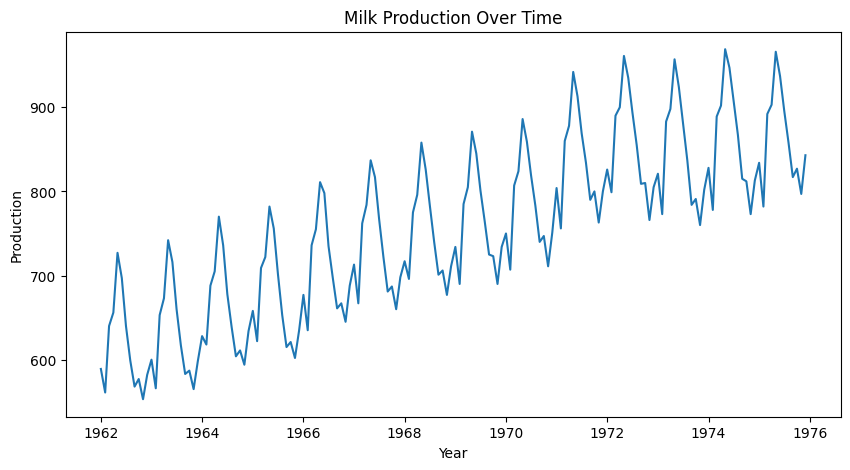

In [7]:
plt.figure(figsize=(10,5))
plt.plot(df['Production'])
plt.title("Milk Production Over Time")
plt.xlabel("Year")
plt.ylabel("Production")
plt.show()


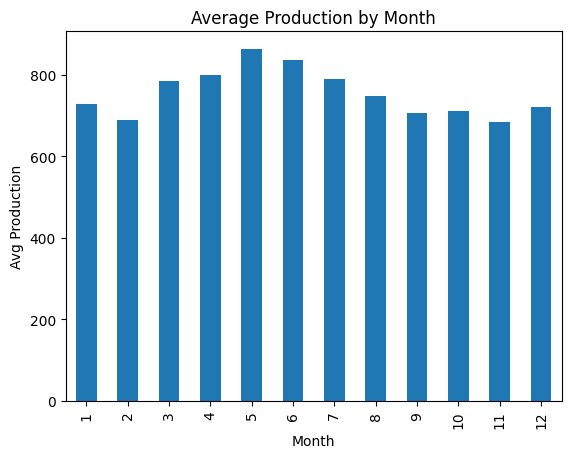

In [8]:
df['Month'] = df.index.month

monthly_avg = df.groupby('Month')['Production'].mean()

monthly_avg.plot(kind='bar', title="Average Production by Month")
plt.xlabel("Month")
plt.ylabel("Avg Production")
plt.show()


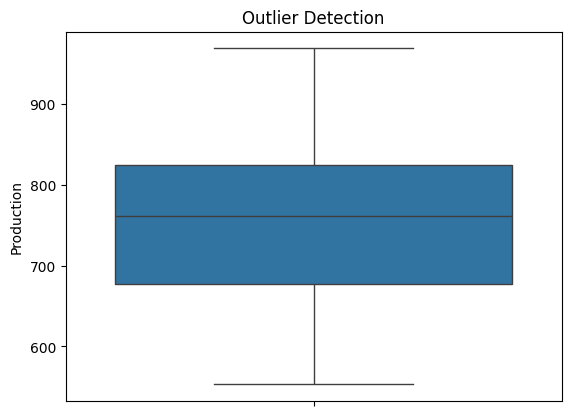

In [9]:
sns.boxplot(df['Production'])
plt.title("Outlier Detection")
plt.show()


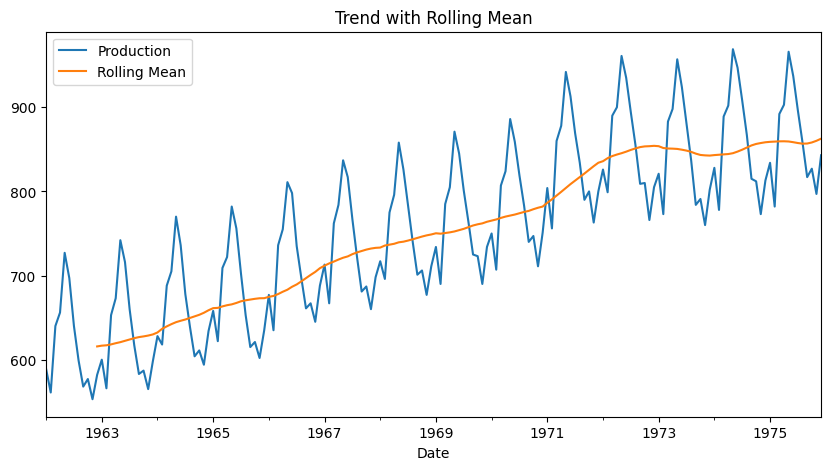

In [10]:
df['Rolling Mean'] = df['Production'].rolling(window=12).mean()

df[['Production', 'Rolling Mean']].plot(figsize=(10,5))
plt.title("Trend with Rolling Mean")
plt.show()


In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['Scaled'] = scaler.fit_transform(df[['Production']])


In [12]:
from sklearn.preprocessing import MinMaxScaler

# Use only production column
data = df[['Production']].values

# Scale data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Function to create sequences
def create_sequences(data, seq_length=12):
    X, y = [], []

    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])   # past 12 months
        y.append(data[i+seq_length])     # next month

    return np.array(X), np.array(y)

# Create sequences
X, y = create_sequences(scaled_data, 12)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (156, 12, 1)
y shape: (156, 1)


In [13]:
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (109, 12, 1)
Validation: (23, 12, 1)
Test: (24, 12, 1)


In [14]:
X_train.shape

(109, 12, 1)

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense


In [16]:
rnn_model = Sequential()

rnn_model.add(SimpleRNN(50, activation='relu', input_shape=(X_train.shape[1], 1)))
rnn_model.add(Dense(1))

rnn_model.compile(optimizer='adam', loss='mse')

history_rnn = rnn_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_val, y_val)
)


Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.3279 - val_loss: 0.5735
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1766 - val_loss: 0.3055
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0896 - val_loss: 0.1344
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0352 - val_loss: 0.0196
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0269 - val_loss: 0.0181
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0185 - val_loss: 0.0316
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0178 - val_loss: 0.0313
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0159 - val_loss: 0.0200
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0142 - val_loss: 0.0142
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0126 - val_loss: 0.0149
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0109 - val_loss: 0.0101
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0093 - val_loss: 0.0091
Epoch 13/20


In [17]:
lstm_model = Sequential()

lstm_model.add(LSTM(50, activation='relu', input_shape=(X_train.shape[1], 1)))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mse')

history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_val, y_val)
)


Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.2213 - val_loss: 0.4947
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.1754 - val_loss: 0.3880
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1297 - val_loss: 0.2678
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0780 - val_loss: 0.1256
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0330 - val_loss: 0.0244
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0304 - val_loss: 0.0321
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0244 - val_loss: 0.0287
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0237 - val_loss: 0.0320
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0219 - val_loss: 0.0226
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0213 - val_loss: 0.0214
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0207 - val_loss: 0.0207
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0202 - val_loss: 0.0215
E

In [18]:
gru_model = Sequential()

gru_model.add(GRU(50, activation='relu', input_shape=(X_train.shape[1], 1)))
gru_model.add(Dense(1))

gru_model.compile(optimizer='adam', loss='mse')

history_gru = gru_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_val, y_val)
)


Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.1643 - val_loss: 0.3251
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1032 - val_loss: 0.2066
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0559 - val_loss: 0.1070
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0302 - val_loss: 0.0434
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0234 - val_loss: 0.0253
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0244 - val_loss: 0.0260
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0213 - val_loss: 0.0344
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0209 - val_loss: 0.0408
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0204 - val_loss: 0.0347
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0198 - val_loss: 0.0290
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0195 - val_loss: 0.0276
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0191 - val_loss: 0.0292
E

In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

def build_model(model_type, units, input_shape):

    model = Sequential()

    if model_type == "LSTM":
        model.add(LSTM(units, input_shape=input_shape))
        model.add(Dense(1))

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model

In [22]:
results = []

for units in units_list:
    for batch in batch_sizes:
        for epochs in epochs_list:

            model = build_model("LSTM", units, (X_train.shape[1], 1))

            history = model.fit(
                X_train, y_train,
                epochs=epochs,
                batch_size=batch,
                validation_split=0.2,
                verbose=0
            )

            final_loss = history.history['val_loss'][-1]

            results.append((units, batch, epochs, final_loss))

            print(f"Units: {units}, Batch: {batch}, Epochs: {epochs}, Val Loss: {final_loss}")


Units: 32, Batch: 16, Epochs: 20, Val Loss: 0.027112483978271484
Units: 32, Batch: 16, Epochs: 30, Val Loss: 0.028823548927903175
Units: 32, Batch: 32, Epochs: 20, Val Loss: 0.038410499691963196
Units: 32, Batch: 32, Epochs: 30, Val Loss: 0.03312884643673897
Units: 50, Batch: 16, Epochs: 20, Val Loss: 0.03030460514128208
Units: 50, Batch: 16, Epochs: 30, Val Loss: 0.017439721152186394
Units: 50, Batch: 32, Epochs: 20, Val Loss: 0.030957428738474846
Units: 50, Batch: 32, Epochs: 30, Val Loss: 0.029666775837540627
Units: 100, Batch: 16, Epochs: 20, Val Loss: 0.024266839027404785
Units: 100, Batch: 16, Epochs: 30, Val Loss: 0.004088124260306358
Units: 100, Batch: 32, Epochs: 20, Val Loss: 0.031136997044086456
Units: 100, Batch: 32, Epochs: 30, Val Loss: 0.02452603541314602


In [23]:
units_list = [32, 50, 100]
batch_sizes = [16, 32]
epochs_list = [20, 30]


In [24]:
best = min(results, key=lambda x: x[3])
print("\nBest Parameters:")
print(f"Units: {best[0]}, Batch: {best[1]}, Epochs: {best[2]}")



Best Parameters:
Units: 100, Batch: 16, Epochs: 30


In [25]:
best_units, best_batch, best_epochs = best[0], best[1], best[2]

final_model = build_model("LSTM", best_units, (X_train.shape[1], 1))

final_model.fit(
    X_train, y_train,
    epochs=best_epochs,
    batch_size=best_batch,
    validation_data=(X_test, y_test)
)


Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0756 - mae: 0.2201 - val_loss: 0.0244 - val_mae: 0.1391
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0361 - mae: 0.1636 - val_loss: 0.0266 - val_mae: 0.1468
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0241 - mae: 0.1329 - val_loss: 0.0456 - val_mae: 0.1612
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0273 - mae: 0.1332 - val_loss: 0.0348 - val_mae: 0.1447
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0241 - mae: 0.1328 - val_loss: 0.0238 - val_mae: 0.1333
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0238 - mae: 0.1370 - val_loss: 0.0242 - val_mae: 0.1299
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0233 - mae: 0.1316 - val_loss: 0.0306 - val_mae: 0.1381
Epoch 8/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0227 - mae: 0.1274 - val_loss: 0.0261 - val_mae: 0.1305
Epoch 9/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0222 - mae: 0.1312 - 

In [26]:
# RNN
rnn_pred = rnn_model.predict(X_test)

# LSTM
lstm_pred = lstm_model.predict(X_test)

# GRU
gru_pred = gru_model.predict(X_test)

# Inverse scaling
rnn_pred = scaler.inverse_transform(rnn_pred)
lstm_pred = scaler.inverse_transform(lstm_pred)
gru_pred = scaler.inverse_transform(gru_pred)

y_test_actual = scaler.inverse_transform(y_test)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 721ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step


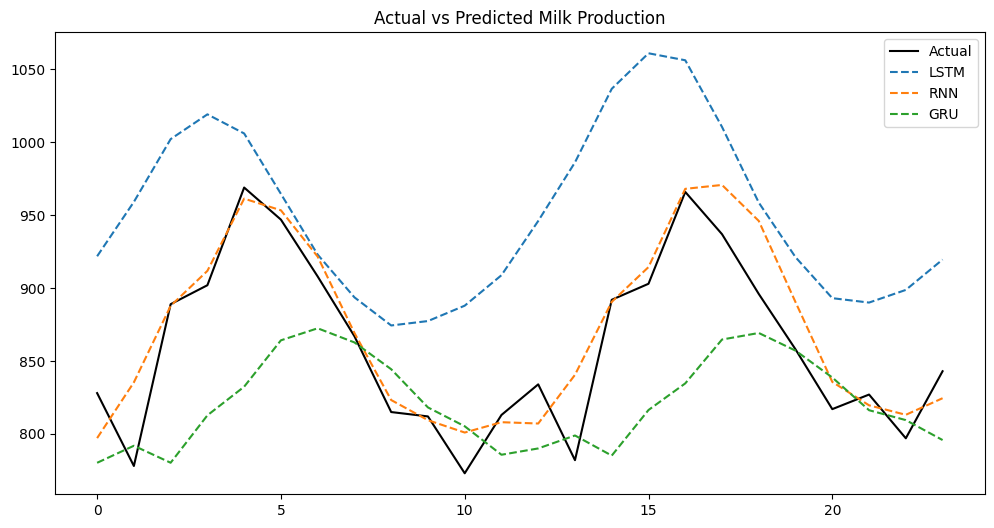

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test_actual, label='Actual', color='black')
plt.plot(lstm_pred, label='LSTM', linestyle='--')
plt.plot(rnn_pred, label='RNN', linestyle='--')
plt.plot(gru_pred, label='GRU', linestyle='--')

plt.title("Actual vs Predicted Milk Production")
plt.legend()
plt.show()


In [28]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def calculate_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return rmse, mae, mape

# RNN
rnn_rmse, rnn_mae, rnn_mape = calculate_metrics(y_test_actual, rnn_pred)

# LSTM
lstm_rmse, lstm_mae, lstm_mape = calculate_metrics(y_test_actual, lstm_pred)

# GRU
gru_rmse, gru_mae, gru_mape = calculate_metrics(y_test_actual, gru_pred)


In [29]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    "RMSE": [rnn_rmse, lstm_rmse, gru_rmse],
    "MAE": [rnn_mae, lstm_mae, gru_mae],
    "MAPE": [rnn_mape, lstm_mape, gru_mape]
})

print(results)


  Model        RMSE        MAE       MAPE
0   RNN   25.417435  18.757271   2.242436
1  LSTM  101.806796  90.169253  10.685036
2   GRU   64.245815  49.654109   5.556192


In [30]:
# Number of future steps
future_steps = 12

# Take last sequence from test data
last_sequence = X_test[-1]

future_predictions = []

current_sequence = last_sequence.copy()

for _ in range(future_steps):
    # Reshape for model
    pred = lstm_model.predict(current_sequence.reshape(1, current_sequence.shape[0], 1))

    future_predictions.append(pred[0][0])

    # Update sequence (slide window)
    current_sequence = np.append(current_sequence[1:], pred, axis=0)

# Convert to array
future_predictions = np.array(future_predictions).reshape(-1,1)

# Inverse scaling
future_predictions = scaler.inverse_transform(future_predictions)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [31]:
# Last date in dataset
last_date = df.index[-1]

# Generate next 12 months
future_dates = pd.date_range(last_date, periods=13, freq='M')[1:]


/tmp/ipykernel_1767/1390800481.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(last_date, periods=13, freq='M')[1:]


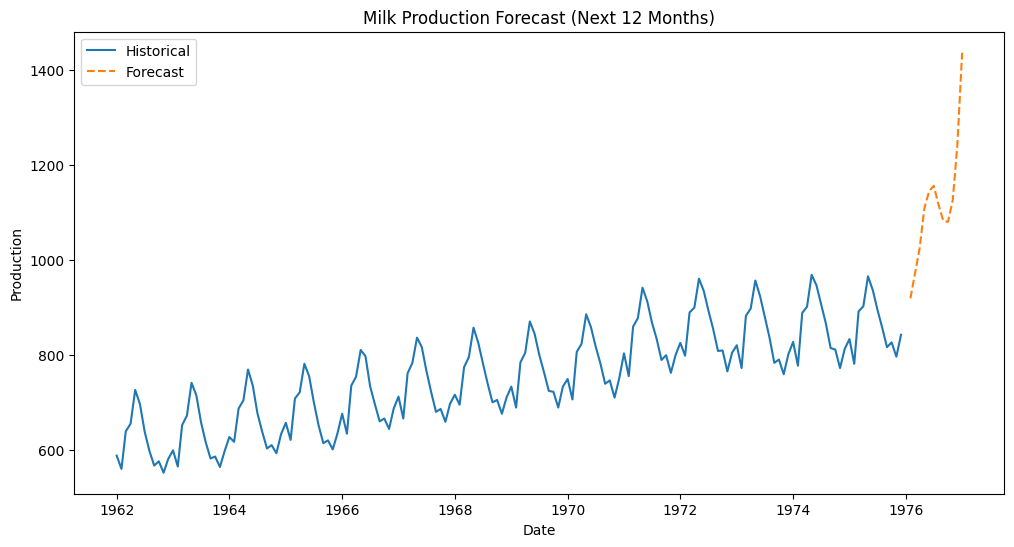

In [32]:
plt.figure(figsize=(12,6))

# Plot historical data
plt.plot(df.index, df['Production'], label='Historical')

# Plot forecast
plt.plot(future_dates, future_predictions, label='Forecast', linestyle='--')

plt.title("Milk Production Forecast (Next 12 Months)")
plt.xlabel("Date")
plt.ylabel("Production")
plt.legend()
plt.show()
